In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def midpoint(P, Q):
    return (P + Q) / 2
def line_intersection(P1, d1, P2, d2):
    # Solve P1 + t*d1 = P2 + s*d2
    A_mat = np.array([d1, -d2]).T
    b = P2 - P1
    t, s = np.linalg.solve(A_mat, b)
    return P1 + t * d1
def foot_of_perpendicular(P, Q, R):
    # foot from P to line QR
    QR = R - Q
    t = np.dot(P - Q, QR) / np.dot(QR, QR)
    return Q + t * QR
def circle_from_3_points(P1, P2, P3):
    temp = P2 - P1
    temp2 = P3 - P1
    A_mat = np.array([
        [temp[0], temp[1]],
        [temp2[0], temp2[1]]
    ])
    b = np.array([
        np.dot(temp, temp) / 2,
        np.dot(temp2, temp2) / 2
    ])
    center = np.linalg.solve(A_mat, b) + P1
    radius = np.linalg.norm(center - P1)
    return center, radius

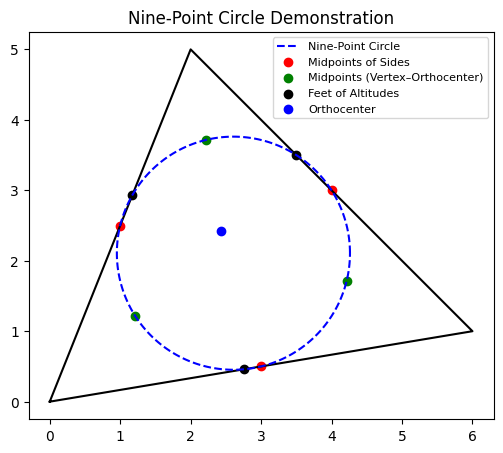

In [ ]:
A = np.array([0, 0])
B = np.array([6, 1])
C = np.array([2, 5])
M_AB = midpoint(A, B)
M_BC = midpoint(B, C)
M_CA = midpoint(C, A)
# --- 3. Orthocenter (intersection of altitudes) ---
# Altitude from A is perpendicular to BC
d_BC = C - B
alt_A_dir = np.array([-d_BC[1], d_BC[0]])
# Altitude from B is perpendicular to AC
d_AC = C - A
alt_B_dir = np.array([-d_AC[1], d_AC[0]])
H = line_intersection(A, alt_A_dir, B, alt_B_dir)
# --- 4. Feet of altitudes ---
F_A = foot_of_perpendicular(A, B, C)
F_B = foot_of_perpendicular(B, A, C)
F_C = foot_of_perpendicular(C, A, B)
# --- 5. Midpoints between vertices and orthocenter ---
N_A = midpoint(A, H)
N_B = midpoint(B, H)
N_C = midpoint(C, H)
# --- 6. Collect all 9 points ---
points = [M_AB, M_BC, M_CA, F_A, F_B, F_C, N_A, N_B, N_C]
points_midpoint1 = [M_AB, M_BC, M_CA]
points_feet = [F_A, F_B, F_C]
points_midpoint2 = [N_A, N_B, N_C] 
# --- 7. Fit a circle (using 3 points: midpoints) ---
center, radius = circle_from_3_points(M_AB, M_BC, M_CA)
# --- 8. Plot everything ---
theta = np.linspace(0, 2*np.pi, 200)
circle_x = center[0] + radius * np.cos(theta)
circle_y = center[1] + radius * np.sin(theta)
plt.figure(figsize=(6,6))
# Triangle
plt.plot([A[0], B[0], C[0], A[0]],
         [A[1], B[1], C[1], A[1]], 'k-')
# Circle
plt.plot(circle_x, circle_y, 'b--', label="Nine-Point Circle")
# Points
for i, p_m in enumerate(points_midpoint1):
    plt.scatter(p_m[0], p_m[1], color='red',
                label="Midpoints of Sides" if i == 0 else "")

for i, p_o in enumerate(points_midpoint2):
    plt.scatter(p_o[0], p_o[1], color="green",
                label="Midpoints (Vertex–Orthocenter)" if i == 0 else "")

for i, p_f in enumerate(points_feet):
    plt.scatter(p_f[0], p_f[1], color="black",
                label="Feet of Altitudes" if i == 0 else "")
# Orthocenter
plt.scatter(H[0], H[1], color='blue', label="Orthocenter")
plt.gca().set_aspect('equal')
plt.legend(fontsize="8")
plt.title("Nine-Point Circle Demonstration")
plt.show()